# Alternative Deterministic Pipeline Including Primary Core Size

This notebook implements an alternative deterministic pipeline that includes primary core size as an additional descriptor (nine descriptors in total), together with an applicability-domain analysis based on the Mahalanobis distance. It uses the same group-aware train/test split protocol and the same three classifiers (Random Forest, linear SVM, MLP) as the main pipeline, evaluated on the same underlying dataset.


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, precision_score, recall_score, f1_score,
                              roc_curve, auc, precision_recall_curve, average_precision_score)
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
colors = ["#2c3e50", "#8c3a3a", "#4a7c7c", "#5b7c99", "#7f8c8d", "#a0522d", "#6b7a8f", "#3d5a6c"]
model_colors = {'Random Forest': colors[0], 'SVM (linear)': colors[1], 'MLP': colors[2]}
RANDOM_SEED = 42


## 1. Data loading

In [2]:
DATA_PATH = "dataset_nanotox_datos_originales.xlsx"
df = pd.read_excel(DATA_PATH)
print(df.shape)
df[['NPs','coresize','hydrosize','surfcharge','surfarea','Ec','Expotime','dosage','e','NOxygen','class']].head()


(483, 24)


,NPs,coresize,hydrosize,surfcharge,surfarea,Ec,Expotime,dosage,e,NOxygen,class
0,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,0.001,1.61,3,nonToxic
1,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,0.010,1.61,3,nonToxic
2,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,0.100,1.61,3,nonToxic
3,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,1.000,1.61,3,nonToxic
4,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,5.000,1.61,3,nonToxic


## 2. Descriptor transformations: nine descriptors (the eight core descriptors plus primary core size)

In [3]:
def normalise(df):
    df = df.copy()
    df['coresize'] = np.log(df['coresize'])
    df['hydrosize'] = np.log(df['hydrosize'])
    df['surfarea'] = np.log(df['surfarea'])
    df['surfcharge'] = StandardScaler().fit_transform(df[['surfcharge']])
    df['Ec'] = np.log(6.17 + df['Ec'])
    df['dosage'] = np.log10(df['dosage'])
    df['Expotime'] = np.log(df['Expotime'] / 3) / np.log(2)
    df['e'] = np.log(df['e'])
    return df

features = ['coresize','hydrosize','surfcharge','surfarea','Ec','Expotime','dosage','e','NOxygen']
df_norm = normalise(df)
df_norm['class_bin'] = df_norm['class'].map({'nonToxic': 0, 'Toxic': 1})
df_norm[features + ['class_bin']].head()


,coresize,hydrosize,surfcharge,surfarea,Ec,Expotime,dosage,e,NOxygen,class_bin
0,3.681351,5.587249,1.656714,4.169761,1.539015,3.0,-3.00000,0.476234,3,0
1,3.681351,5.587249,1.656714,4.169761,1.539015,3.0,-2.00000,0.476234,3,0
2,3.681351,5.587249,1.656714,4.169761,1.539015,3.0,-1.00000,0.476234,3,0
3,3.681351,5.587249,1.656714,4.169761,1.539015,3.0,0.00000,0.476234,3,0
4,3.681351,5.587249,1.656714,4.169761,1.539015,3.0,0.69897,0.476234,3,0


## 3. Group-aware train/test split and class balancing

In [4]:
df['_group_key'] = df[features].astype(str).agg('|'.join, axis=1)
df_norm['_group_key'] = df['_group_key'].values
print(f"Rows: {len(df)}  Unique experimental conditions (9 descriptors): {df['_group_key'].nunique()}")

group_majority = df_norm.groupby('_group_key')['class_bin'].agg(lambda s: s.mode().iloc[0])
groups = group_majority.index.values
group_labels = group_majority.values

train_groups, test_groups = train_test_split(
    groups, test_size=0.20, random_state=RANDOM_SEED, stratify=group_labels
)
train_groups, test_groups = set(train_groups), set(test_groups)

train_mask = df_norm['_group_key'].isin(train_groups)
test_mask = df_norm['_group_key'].isin(test_groups)
assert (train_mask | test_mask).all() and not (train_mask & test_mask).any()

X_train_raw = df_norm.loc[train_mask, features]
y_train_raw = df_norm.loc[train_mask, 'class_bin']
X_test = df_norm.loc[test_mask, features]
y_test = df_norm.loc[test_mask, 'class_bin']

print(f"Train: {len(X_train_raw)} rows (non-toxic={(y_train_raw==0).sum()}, toxic={(y_train_raw==1).sum()})")
print(f"Test:  {len(X_test)} rows (non-toxic={(y_test==0).sum()}, toxic={(y_test==1).sum()})")

smote = SMOTE(random_state=RANDOM_SEED)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)
print(f"Training set after SMOTE: non-toxic={(y_train==0).sum()}, toxic={(y_train==1).sum()}")


Rows: 483  Unique experimental conditions (9 descriptors): 353
Train: 394 rows (non-toxic=328, toxic=66)
Test:  89 rows (non-toxic=77, toxic=12)
Training set after SMOTE: non-toxic=328, toxic=328


## 4. Model training

In [5]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'SVM (linear)': SVC(kernel='linear', probability=True, random_state=RANDOM_SEED, class_weight='balanced'),
    'MLP': MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=RANDOM_SEED),
}

y_preds, y_probs = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_preds[name] = model.predict(X_test)
    y_probs[name] = model.predict_proba(X_test)[:, 1]
    print(f'--- {name} ---')
    print(classification_report(y_test, y_preds[name], target_names=['nonToxic','Toxic']))
    print(confusion_matrix(y_test, y_preds[name]))
    print()


--- Random Forest ---


              precision    recall  f1-score   support

    nonToxic       0.94      0.99      0.96        77
       Toxic       0.88      0.58      0.70        12

    accuracy                           0.93        89
   macro avg       0.91      0.79      0.83        89
weighted avg       0.93      0.93      0.93        89

[[76  1]
 [ 5  7]]

--- SVM (linear) ---
              precision    recall  f1-score   support

    nonToxic       0.99      0.95      0.97        77
       Toxic       0.73      0.92      0.81        12

    accuracy                           0.94        89
   macro avg       0.86      0.93      0.89        89
weighted avg       0.95      0.94      0.95        89

[[73  4]
 [ 1 11]]



--- MLP ---
              precision    recall  f1-score   support

    nonToxic       0.97      0.99      0.98        77
       Toxic       0.91      0.83      0.87        12

    accuracy                           0.97        89
   macro avg       0.94      0.91      0.93        89
weighted avg       0.97      0.97      0.97        89

[[76  1]
 [ 2 10]]



## 5. Applicability domain analysis (Mahalanobis distance)

An instance is flagged as outside the applicability domain of the training set if its Mahalanobis distance to the training-set centroid exceeds the chi-squared critical value at a 95% confidence level, with degrees of freedom equal to the number of descriptors. The analysis is applied to every instance in the test set.

In [6]:
def in_applicability_domain(X_train, X_new, confidence=0.95):
    X_arr = np.array(X_train)
    mean = X_arr.mean(axis=0)
    cov = np.cov(X_arr, rowvar=False)
    inv_cov = np.linalg.pinv(cov)
    dist = mahalanobis(np.array(X_new), mean, inv_cov)
    threshold = np.sqrt(chi2.ppf(confidence, df=X_arr.shape[1]))
    return dist <= threshold, float(dist), float(threshold)

domain_results = []
for idx in range(len(X_test)):
    sample = X_test.iloc[idx]
    in_domain, dist, threshold = in_applicability_domain(X_train_raw, sample)
    domain_results.append({'index': X_test.index[idx], 'in_domain': in_domain, 'distance': dist})

domain_df = pd.DataFrame(domain_results)
n_out = (~domain_df['in_domain']).sum()
print(f"Mahalanobis threshold (95% confidence, {len(features)} degrees of freedom): {threshold:.3f}")
print(f"Test instances outside the applicability domain: {n_out} of {len(X_test)} ({100*n_out/len(X_test):.1f}%)")
domain_df.sort_values('distance', ascending=False).head(10)


Mahalanobis threshold (95% confidence, 9 degrees of freedom): 4.113
Test instances outside the applicability domain: 14 of 89 (15.7%)


,index,in_domain,distance
1,10,False,4.913934
0,7,False,4.876226
2,14,False,4.822773
9,53,False,4.440102
8,44,False,4.433552
6,25,False,4.340933
5,23,False,4.288207
4,22,False,4.272887
3,21,False,4.254821
7,32,False,4.225816


## 6. Confusion matrices, ROC and precision-recall curves

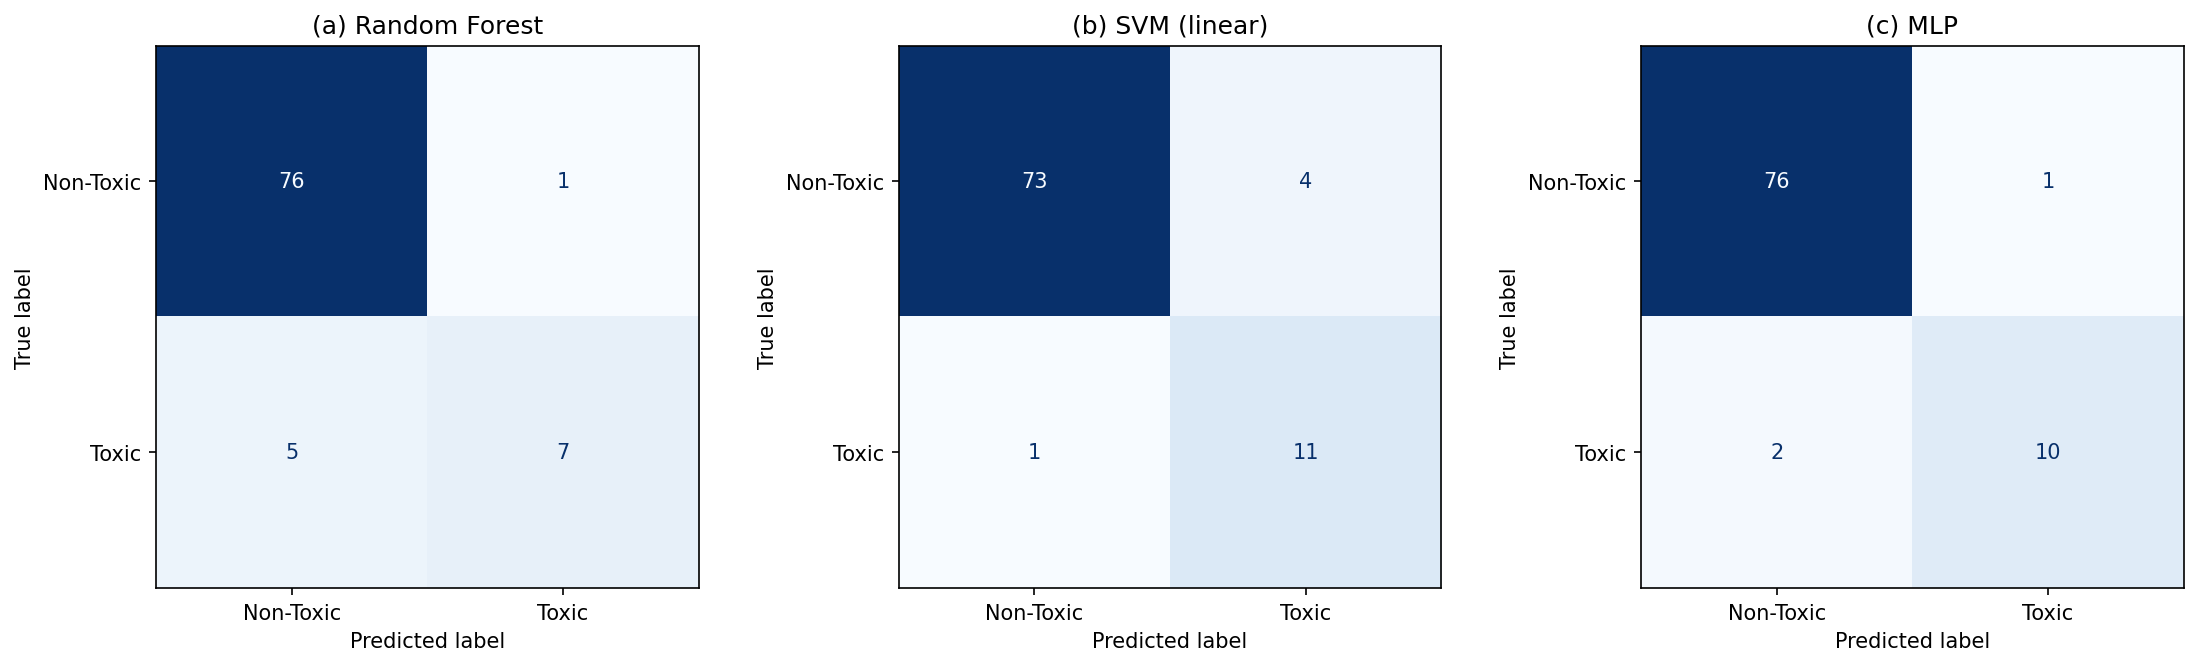

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for idx, name in enumerate(models):
    cm = confusion_matrix(y_test, y_preds[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Toxic', 'Toxic'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'({chr(97+idx)}) {name}')
plt.tight_layout()
plt.savefig('applicability_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


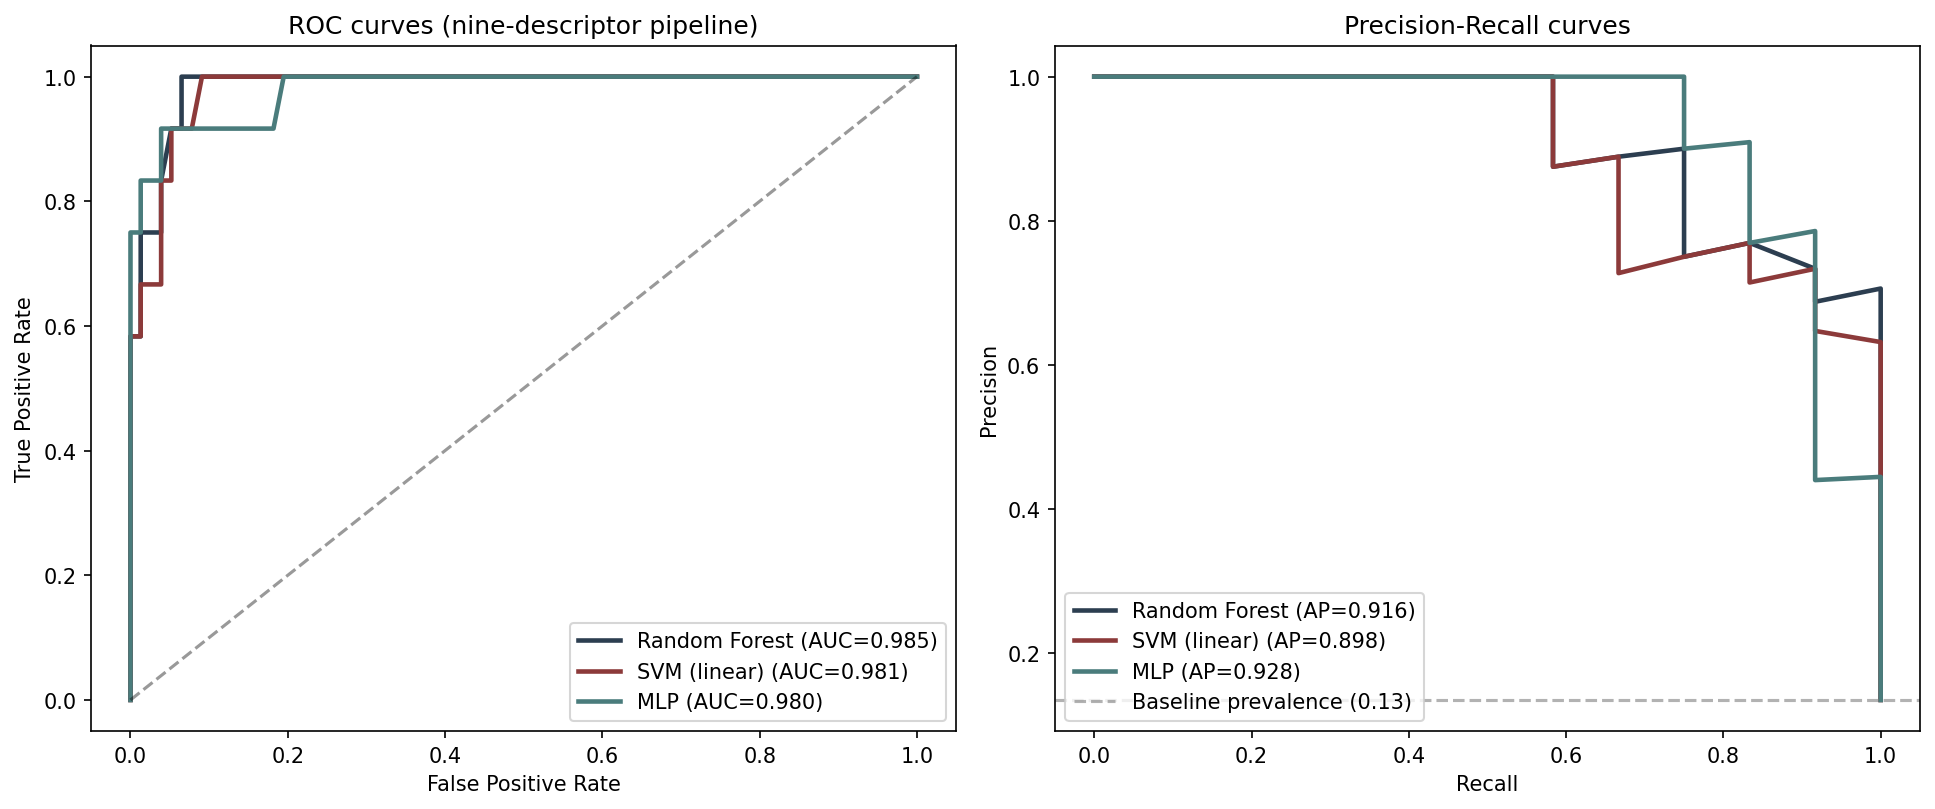

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for name in models:
    fpr_c, tpr_c, _ = roc_curve(y_test, y_probs[name])
    roc_auc = auc(fpr_c, tpr_c)
    axes[0].plot(fpr_c, tpr_c, linewidth=2.2, color=model_colors[name], label=f'{name} (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curves (nine-descriptor pipeline)'); axes[0].legend(loc='lower right')

baseline = (y_test==1).mean()
for name in models:
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_probs[name])
    ap = average_precision_score(y_test, y_probs[name])
    axes[1].plot(rec_c, prec_c, linewidth=2.2, color=model_colors[name], label=f'{name} (AP={ap:.3f})')
axes[1].axhline(baseline, color='gray', linestyle='--', alpha=0.6, label=f'Baseline prevalence ({baseline:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curves'); axes[1].legend(loc='lower left')
plt.tight_layout()
plt.savefig('applicability_roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Feature importance (Random Forest, nine descriptors)

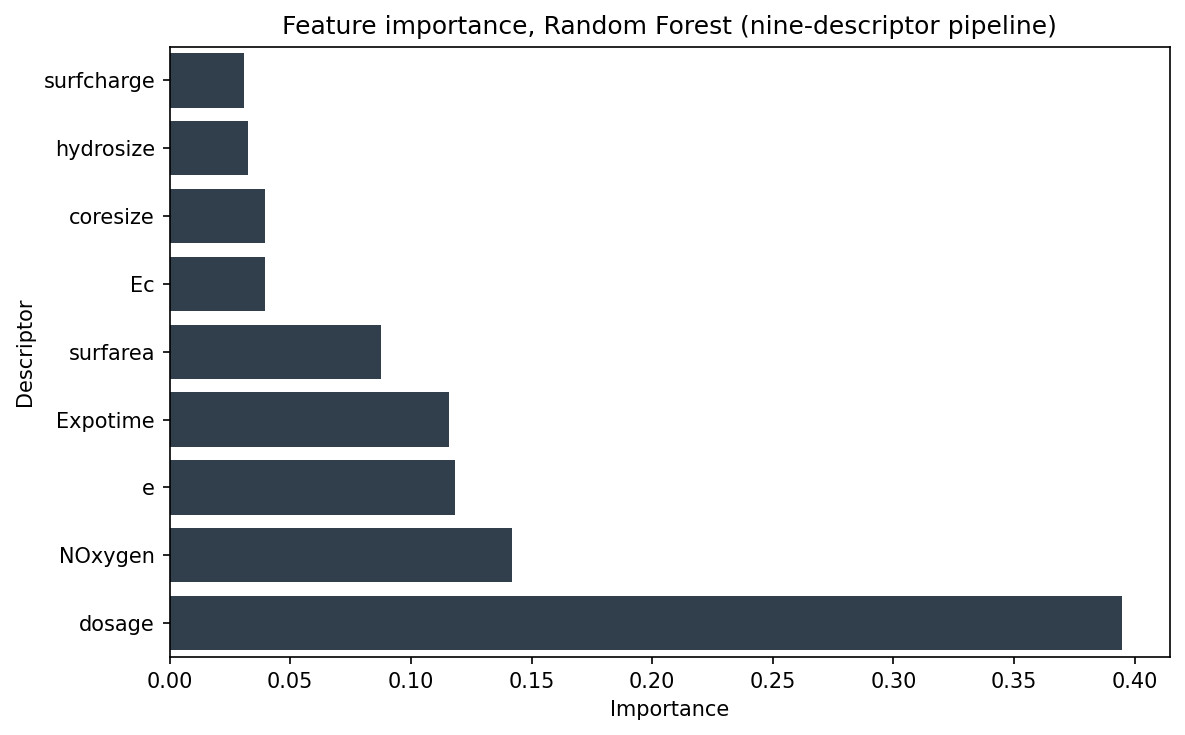

In [9]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
plt.figure(figsize=(8,5))
order = np.argsort(importances)
sns.barplot(x=importances[order], y=np.array(features)[order], color=colors[0])
plt.title('Feature importance, Random Forest (nine-descriptor pipeline)')
plt.xlabel('Importance'); plt.ylabel('Descriptor')
plt.tight_layout()
plt.savefig('applicability_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


## 8. Summary

In [10]:
rows = []
for name in models:
    y_pred, y_prob = y_preds[name], y_probs[name]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    fnr = fn / (fn + tp)
    fpr_curve, tpr_curve, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr_curve, tpr_curve)
    pr_auc = average_precision_score(y_test, y_prob)
    rows.append([name, acc, rec, prec, f1, fnr, roc_auc, pr_auc])

summary = pd.DataFrame(rows, columns=['Model','Accuracy','Recall','Precision','F1','FNR','ROC-AUC','PR-AUC']).set_index('Model').round(3)
summary.to_csv('applicability_summary.csv')
print(f"Test set size: {len(X_test)}  (non-toxic={(y_test==0).sum()}, toxic={(y_test==1).sum()})")
summary


Test set size: 89  (non-toxic=77, toxic=12)


,Accuracy,Recall,Precision,F1,FNR,ROC-AUC,PR-AUC
Model,,,,,,,
Random Forest,0.933,0.583,0.875,0.700,0.417,0.985,0.916
SVM (linear),0.944,0.917,0.733,0.815,0.083,0.981,0.898
MLP,0.966,0.833,0.909,0.870,0.167,0.980,0.928
